<img src = "https://drive.google.com/uc?export=view&id=1VV2e_u46fNm_ewns8QW2HGRZAPHh-e2t" alt = "Encabezado MLDS" width = "100%">  </img>

## **0. Integrantes del equipo de trabajo**
---

1. Ivonne Alexandra Guevara Prieto - CC 1032376081

## **Setup: Librerías, semillas y recarga de datos**
---

Recargamos librerías, semillas y los pares preprocesados construidos previamente.

In [1]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import os, random
import pandas as pd
import cv2
%matplotlib inline
plt.style.use("ggplot")

# Configuración de semillas para reproducibilidad
random.seed(0)
keras.utils.set_random_seed(0)
tf.random.set_seed(0)
np.random.seed(0)


In [2]:
import kagglehub

path       = kagglehub.dataset_download("robinreni/signature-verification-dataset")
base_path  = path
train_path = os.path.join(base_path, "sign_data/train")
test_path  = os.path.join(base_path, "sign_data/test")

train_csv = pd.read_csv(os.path.join(base_path, "sign_data/train_data.csv"), header=None)
test_csv  = pd.read_csv(os.path.join(base_path, "sign_data/test_data.csv"),  header=None)
train_csv.rename(columns={0: 'image_original_name', 1: 'image_comparison_name', 2: 'label'}, inplace=True)
test_csv.rename( columns={0: 'image_original_name', 1: 'image_comparison_name', 2: 'label'}, inplace=True)

print("Dataset cargado.")

100%|██████████| 601M/601M [00:26<00:00, 23.9MB/s]

Extracting files...


Dataset cargado.


In [3]:
# Función de preprocesamiento (definida en M5U3)
def preprocesar_imagen(ruta_img, tam=(105, 105)):
    """
    Preprocesa una imagen para la Red Siamesa:
    1. Carga en escala de grises.
    2. Redimensiona a tam (105x105 por defecto).
    3. Normaliza píxeles al rango [0, 1].
    4. Agrega dimensión de canal → shape (105, 105, 1).
    """
    img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, tam)
    img = img / 255.0
    return img.reshape(tam[0], tam[1], 1)

# Función de construcción de pares (definida en M5U3)
def construir_pares_desde_csv(df, base_img_folder):
    """
    Construye arreglos de pares de imágenes y etiquetas desde el CSV.
    Retorna:
        pares  : np.array de shape (N, 2, 105, 105, 1)
        labels : np.array de shape (N,)
    """
    pares, labels = [], []
    omitidos = 0
    for _, row in df.iterrows():
        ruta_a = os.path.join(base_img_folder, row['image_original_name'])
        ruta_b = os.path.join(base_img_folder, row['image_comparison_name'])
        if os.path.exists(ruta_a) and os.path.exists(ruta_b):
            pares.append([preprocesar_imagen(ruta_a), preprocesar_imagen(ruta_b)])
            labels.append(row['label'])
        else:
            omitidos += 1
    print(f"  Pares construidos: {len(pares)} | Omitidos: {omitidos}")
    return np.array(pares), np.array(labels)

print("Construyendo pares de entrenamiento...")
pares_train, labels_train = construir_pares_desde_csv(train_csv, train_path)
print("Construyendo pares de prueba...")
pares_test, labels_test   = construir_pares_desde_csv(test_csv, test_path)

print(f"\nShape pares_train  : {pares_train.shape}")
print(f"Shape pares_test   : {pares_test.shape}")

Construyendo pares de entrenamiento...
  Pares construidos: 23206 | Omitidos: 0
Construyendo pares de prueba...
  Pares construidos: 5748 | Omitidos: 0

Shape pares_train  : (23206, 2, 105, 105, 1)
Shape pares_test   : (5748, 2, 105, 105, 1)


# **Diseño e implementación experimental**
---


## **1. Particion del conjunto de datos**
---

El dataset **ya incluye** una partición oficial en conjuntos de entrenamiento y prueba a través de los archivos train_data.csv y test_data.csv. Se respeta esta partición original y se separa adicionalmente un conjunto de **validación** del conjunto de entrenamiento.

La estrategia de partición es:

| Conjunto | Origen | Proporción | Uso |
|---|---|---|---|
| **Train** | train_data.csv (80%) | ~80% del total | Ajuste de pesos del modelo |
| **Validación** | train_data.csv (20%) | ~20% de train | Selección de hiperparámetros y early stopping |
| **Test** | test_data.csv (100%) | ~20% del total | Evaluación final con datos no vistos |

In [4]:
from sklearn.model_selection import train_test_split

# Separar validación del conjunto de entrenamiento (80/20 estratificado)
pares_tr, pares_val, labels_tr, labels_val = train_test_split(
    pares_train, labels_train,
    test_size=0.2,
    random_state=42,
    stratify=labels_train
)

print("=" * 48)
print("          RESUMEN DE LA PARTICIÓN")
print("=" * 48)
print(f"  Train       : {len(pares_tr):>5} pares  | "
      f"Genuinos: {np.sum(labels_tr==0):>4} | Falsif.: {np.sum(labels_tr==1):>4}")
print(f"  Validación  : {len(pares_val):>5} pares  | "
      f"Genuinos: {np.sum(labels_val==0):>4} | Falsif.: {np.sum(labels_val==1):>4}")
print(f"  Test        : {len(pares_test):>5} pares  | "
      f"Genuinos: {np.sum(labels_test==0):>4} | Falsif.: {np.sum(labels_test==1):>4}")
print("=" * 48)

          RESUMEN DE LA PARTICIÓN
  Train       : 18564 pares  | Genuinos: 10081 | Falsif.: 8483
  Validación  :  4642 pares  | Genuinos: 2521 | Falsif.: 2121
  Test        :  5748 pares  | Genuinos: 2772 | Falsif.: 2976


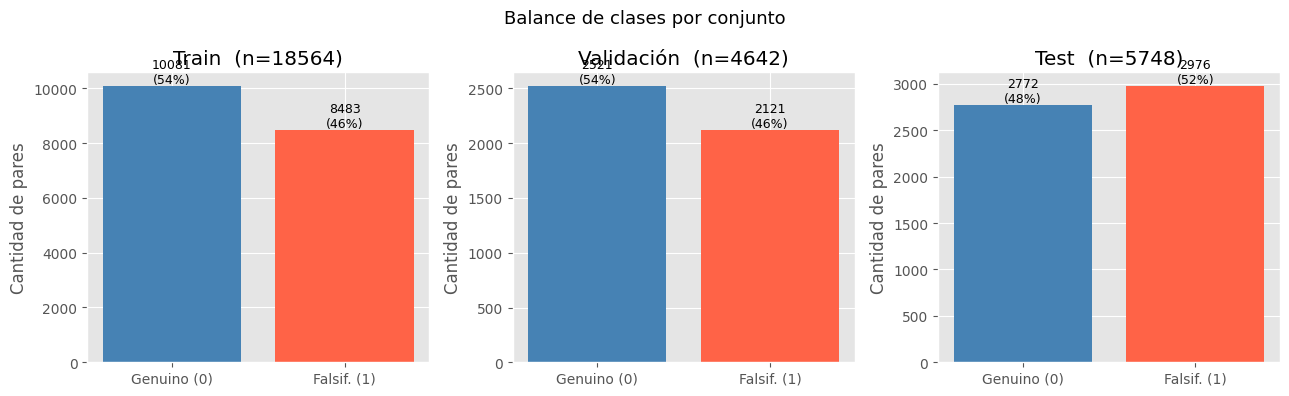

In [5]:
# Visualización del balance en cada split
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Balance de clases por conjunto', fontsize=13)

splits = [
    ('Train',      labels_tr),
    ('Validación', labels_val),
    ('Test',       labels_test)
]

for ax, (nombre, labels) in zip(axes, splits):
    conteos = [np.sum(labels == 0), np.sum(labels == 1)]
    bars = ax.bar(['Genuino (0)', 'Falsif. (1)'], conteos,
                  color=['steelblue', 'tomato'])
    ax.set_title(f'{nombre}  (n={len(labels)})')
    ax.set_ylabel('Cantidad de pares')
    for bar, val in zip(bars, conteos):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({val/len(labels)*100:.0f}%)',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Conclusión de la partición:** La partición estratificada (stratify=labels) preserva la distribución original de clases en cada split. El balance es consistente entre train, validación y test, lo que garantiza que las métricas de evaluación sean representativas del comportamiento real del modelo.

## **2. Selección y diseño de modelos**
---


**RESPUESTA**

---

Ya que el problema es de análisis de imagen, se trabaja con redes neuronales convolucionales siamesas.

### Tipo de problema

El problema es de **clasificación binaria sobre pares de imágenes**: dado un par de firmas $(A, B)$, el modelo debe predecir si son del mismo autor (0 = genuino) o si una es una falsificación (1 = falsificado).

### Modelos a explorar

<img src="https://drive.google.com/uc?export=view&id=1KnZSWxLu4jZDTY-hsL7vk5jxK5wc-bfZ" alt="Red siamesa básica" width="50%">

**Figura 1: Red siamesa basica$^{[5]}$**

Se explorarán **dos modelos** de redes siamesas que serán comparados posteriormente:

#### Modelo 1 — Red Siamesa con CNN base (modelo principal)

Una **Red Siamesa** consiste en dos ramas con pesos compartidos que procesan simultáneamente las dos firmas del par. Cada rama aplica la misma CNN para extraer un vector de características (*embedding*) de cada firma. Luego, la distancia L1 entre los dos embeddings alimenta una capa densa final con activación sigmoide que produce el score de similitud.

**Justificación de la elección:**
* El problema es de **comparación por pares**, no de clasificación individual — las Siamese Networks están diseñadas específicamente para esto.
* El dataset tiene un número moderado de ejemplos por persona. Las redes Siamesas son eficientes con **pocos ejemplos por clase** gracias al aprendizaje de métricas de similitud.
* El uso de **pesos compartidos** entre las dos ramas garantiza que ambas firmas sean procesadas con la misma función de embedding, haciendo la comparación simétrica y consistente.
* La **distancia L1** entre embeddings captura diferencias sutiles en trazos, presión e inclinación, que son las señales discriminativas en firmas manuscritas.

**Arquitectura de la CNN base:**

| Bloque | Capa | Parámetros |
|---|---|---|
| Data Augmentation | RandomFlip, RandomRotation(0.05), RandomZoom(0.05) | Solo en entrenamiento |
| Conv 1 | Conv2D(64, 10×10) + ReLU + MaxPooling + Dropout(0.3) | Extrae bordes y trazos gruesos |
| Conv 2 | Conv2D(128, 7×7) + ReLU + MaxPooling + Dropout(0.3) | Extrae patrones intermedios |
| Conv 3 | Conv2D(128, 4×4) + ReLU + MaxPooling | Extrae características de alto nivel |
| Embedding | Flatten + Dense(4096, sigmoid) | Vector de representación de la firma |

#### Modelo 2 — Red Siamesa con EfficientNetB0 como base (modelo de comparación)

Como modelo de comparación se usará **Transfer Learning con EfficientNetB0** preentrenada en ImageNet como extractor de características dentro de la misma arquitectura Siamesa. Esto permite evaluar si las características aprendidas en imágenes naturales son transferibles al dominio de firmas manuscritas.

**Justificación:**
* Permite comparar directamente el valor de **aprender desde cero** (Modelo 1) vs. **reutilizar conocimiento previo** (Modelo 2).
* EfficientNetB0 es el modelo más ligero de la familia EfficientNet, lo que equilibra rendimiento y costo computacional.
* El curso incluye Transfer Learning como herramienta central del módulo, por lo que es pertinente incluirlo como línea base de comparación.

### Función de pérdida y métricas

Ambos modelos usarán:
* **Pérdida:** binary_crossentropy — estándar para clasificación binaria.
* **Métricas:** accuracy + AUC — el AUC es la métrica principal dado que en detección de fraude interesa el ranking de riesgo, no solo el umbral fijo de 0.5.
----
[5] https://medium.com/@prabhnoor0212/siamese-network-keras-31a3a8f37d04

## **3. Implementación de los modelos**
---

### **3.1. Data Augmentation**
---

Definimos el bloque de aumento de datos. Siguiendo el patrón del curso, se integra directamente en la arquitectura del modelo como una capa Sequential, de modo que solo se activa durante el entrenamiento.

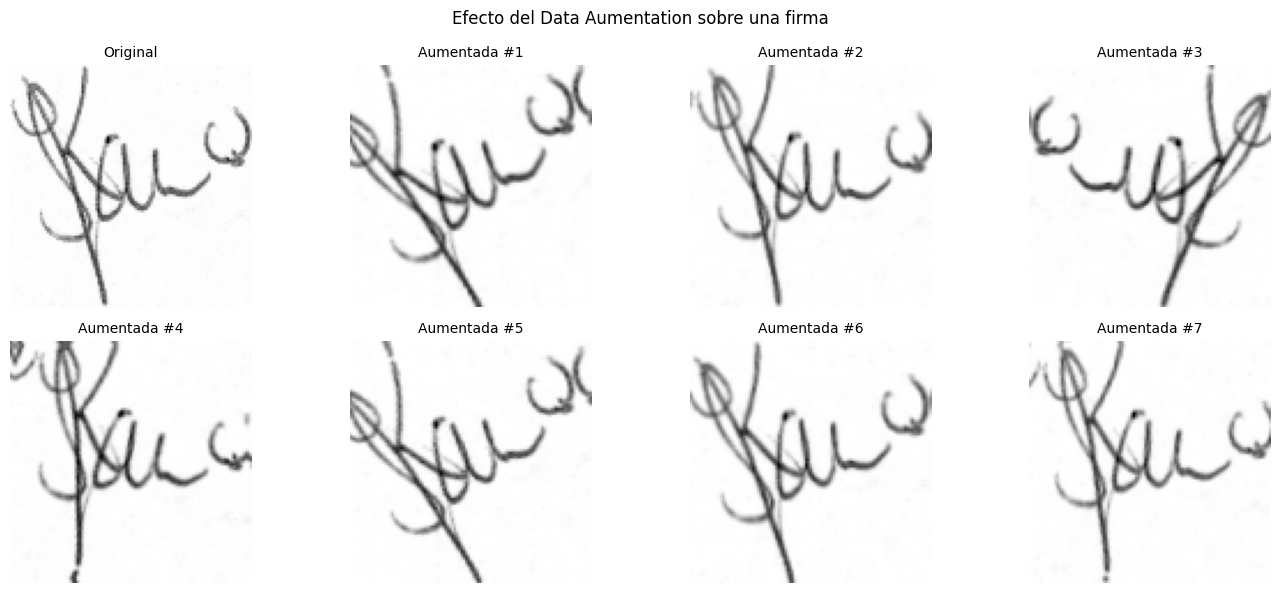

In [14]:
# Bloque de data augmentation (integrado en el modelo, solo activo en entrenamiento)
data_augmentation = keras.Sequential(
    [
        keras.layers.Input(shape=(105, 105, 1)),
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(factor=0.05),
        keras.layers.RandomZoom(height_factor=0.05, width_factor=0.05),
    ],
    name="data_augmentation"
)

# Visualizamos el efecto de la aumentation sobre una firma de ejemplo
img_ejemplo = pares_tr[0, 0]  # Primera imagen del primer par de entrenamiento

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Efecto del Data Aumentation sobre una firma', fontsize=12)

axes[0, 0].imshow(img_ejemplo.reshape(105, 105), cmap='gray')
axes[0, 0].set_title('Original', fontsize=10)
axes[0, 0].axis('off')

for i in range(1, 4):
    aug = data_augmentation(np.expand_dims(img_ejemplo, 0), training=True).numpy()[0]
    axes[0, i].imshow(aug.reshape(105, 105), cmap='gray')
    axes[0, i].set_title(f'Aumentada #{i}', fontsize=10)
    axes[0, i].axis('off')

for i in range(4):
    aug = data_augmentation(np.expand_dims(img_ejemplo, 0), training=True).numpy()[0]
    axes[1, i].imshow(aug.reshape(105, 105), cmap='gray')
    axes[1, i].set_title(f'Aumentada #{i+4}', fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Las transformaciones de augmentation fueron elegidas cuidadosamente para el dominio de firmas: se usa rotación leve (±5%) y zoom (±5%) porque las firmas pueden tener pequeñas variaciones de inclinación y escala entre escrituras del mismo autor. Se evita rotaciones grandes o flip vertical porque distorsionarían la estructura natural de la firma y generarían ejemplos irreales.

### **3.2. Modelo 1 — Red Siamesa con CNN base**
---

In [7]:
# ── RED BASE (CNN) ────────────────────────────────────────────────────────
# Construida con keras.models.Sequential + .add(), siguiendo el estilo del curso

INPUT_SHAPE = (105, 105, 1)

def construir_red_base():
    """
    Construye la red CNN base de la Red Siamesa.
    Extrae un vector de embedding de 4096 dimensiones para cada firma.
    Incluye data augmentation como primera capa.
    """
    red_base = keras.models.Sequential(name='red_base')

    # Data augmentation (solo activo en entrenamiento)
    red_base.add(keras.layers.Input(shape=INPUT_SHAPE))
    red_base.add(data_augmentation)

    # Bloque convolucional 1
    red_base.add(keras.layers.Conv2D(filters=64,
                                     kernel_size=(10, 10),
                                     activation='relu'))
    red_base.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    red_base.add(keras.layers.Dropout(0.3))

    # Bloque convolucional 2
    red_base.add(keras.layers.Conv2D(filters=128,
                                     kernel_size=(7, 7),
                                     activation='relu'))
    red_base.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
    red_base.add(keras.layers.Dropout(0.3))

    # Bloque convolucional 3
    red_base.add(keras.layers.Conv2D(filters=128,
                                     kernel_size=(4, 4),
                                     activation='relu'))
    red_base.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

    # Capa de embedding
    red_base.add(keras.layers.Flatten())
    red_base.add(keras.layers.Dense(units=4096,
                                    activation='sigmoid'))
    return red_base

red_base = construir_red_base()
red_base.summary()

Model: "red_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 105, 105, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 64)     │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 42, 42, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 21, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 21, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 18, 18, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    42,471,424 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,141,696 (164.57 MB)

 Trainable params: 43,141,696 (164.57 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ── ARQUITECTURA SIAMESA COMPLETA ─────────────────────────────────────────
# Functional API: dos entradas, pesos compartidos (misma red_base), distancia L1

# Dos entradas: firma de referencia y firma sospechosa
entrada_a = keras.layers.Input(shape=INPUT_SHAPE, name='firma_referencia')
entrada_b = keras.layers.Input(shape=INPUT_SHAPE, name='firma_sospechosa')

# Pesos compartidos: la misma red_base procesa ambas entradas
embedding_a = red_base(entrada_a)
embedding_b = red_base(entrada_b)

# Distancia L1 entre los embeddings
distancia_L1 = keras.layers.Lambda(
    lambda tensors: keras.ops.abs(tensors[0] - tensors[1]),
    name='distancia_L1'
)([embedding_a, embedding_b])

# Capa de salida: score de similitud en [0, 1]
# 0 = genuino (firmas similares), 1 = falsificado (firmas distintas)
salida = keras.layers.Dense(units=1,
                             activation='sigmoid',
                             name='clasificador')(distancia_L1)

# Definición del modelo completo
modelo_siames = keras.models.Model(
    inputs=[entrada_a, entrada_b],
    outputs=salida,
    name='Red_Siamesa_CNN'
)

modelo_siames.summary()

Model: "Red_Siamesa_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ firma_referencia    │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ firma_sospechosa    │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ red_base            │ (None, 4096)      │ 43,141,696 │ firma_referencia… │
│ (Sequential)        │                   │            │ firma_sospechosa… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distancia_L1        │ (None, 4096)      │          0 │ red_base[0][0],   │
│ (Lambda)            │                   │            │ red_base[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clasificador        │ (None, 1)         │      4,097 │ distancia_L1[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,145,793 (164.59 MB)

 Trainable params: 43,145,793 (164.59 MB)

 Non-trainable params: 0 (0.00 B)

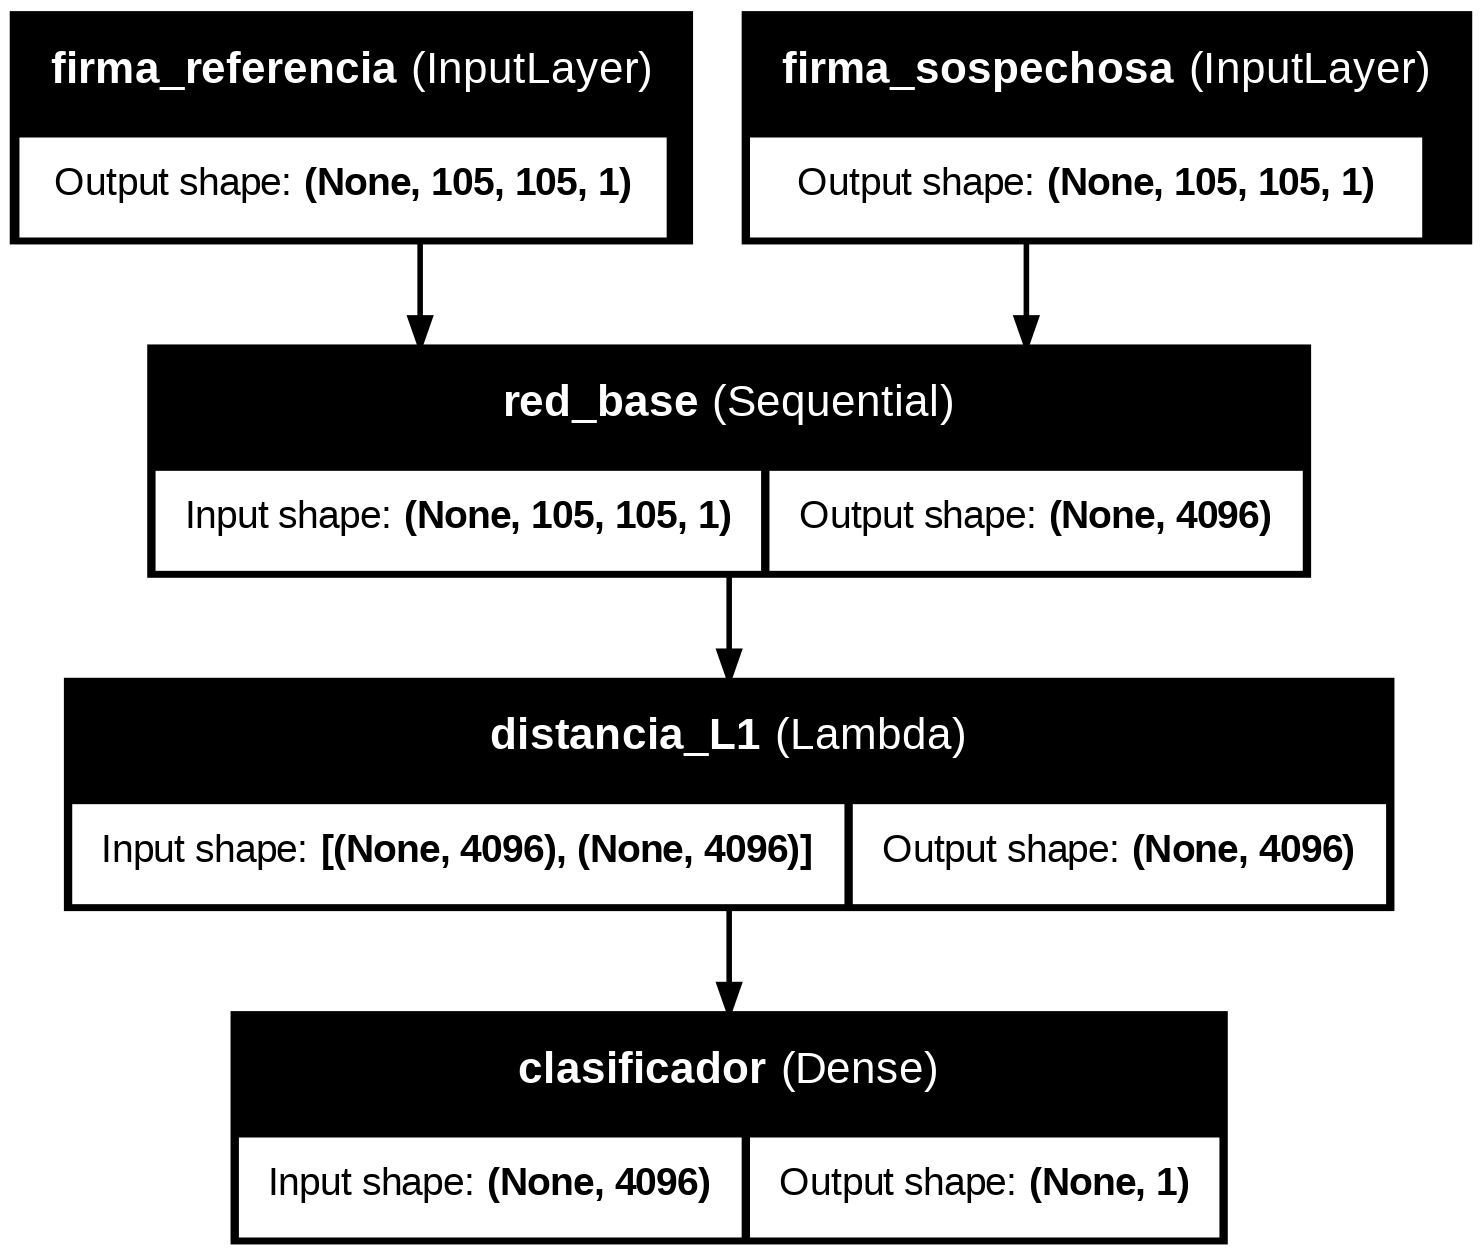

In [16]:
# Diagrama visual de la arquitectura
keras.utils.plot_model(modelo_siames, show_shapes=True, show_layer_names=True)

La capa de embedding de 4096 dimensiones con activación sigmoide comprime toda la información visual de la firma en un vector denso. La activación sigmoide acota cada dimensión en [0,1], lo que hace que la distancia L1 resultante sea siempre no negativa y acotada — condición deseable para un score de similitud.

In [10]:
# Compilación del Modelo 1
modelo_siames.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

print(f"Total de parámetros entrenables: {modelo_siames.count_params():,}")

Total de parámetros entrenables: 43,145,793


### **3.3. Modelo 2 — Red Siamesa con EfficientNetB0 (Transfer Learning)**
---

Como modelo de comparación, reemplazamos la CNN base por un extractor EfficientNetB0 preentrenado en ImageNet. Las imágenes de firmas (1 canal) se convierten a 3 canales para compatibilidad con EfficientNetB0.

In [11]:
# ── RED BASE CON EFFICIENTNETB0 ───────────────────────────────────────────

# Cargamos EfficientNetB0 sin el top (capas densas del final)
extractor = keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(105, 105, 3)
)

# Congelamos el extractor de características (Transfer Learning puro)
for layer in extractor.layers:
    layer.trainable = False

def construir_red_base_efficientnet():
    """
    Construye la red base con EfficientNetB0 como extractor.
    Convierte imágenes de 1 canal a 3 canales para compatibilidad.
    """
    entradas = keras.layers.Input(shape=INPUT_SHAPE, name='entrada_efficientnet')

    # Convertir 1 canal → 3 canales (requerido por EfficientNetB0)
    x = keras.layers.Conv2D(filters=3,
                             kernel_size=(1, 1),
                             padding='same',
                             name='canal_adapter')(entradas)

    # Extractor de características preentrenado
    x = extractor(x, training=False)

    # Reducción de dimensiones + embedding
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(units=512, activation='relu')(x)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(units=4096, activation='sigmoid', name='embedding')(x)

    return keras.models.Model(entradas, x, name='red_base_efficientnet')

red_base_eff = construir_red_base_efficientnet()
red_base_eff.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "red_base_efficientnet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_efficientnet            │ (None, 105, 105, 1)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ canal_adapter (Conv2D)          │ (None, 105, 105, 3)    │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 4096)           │     2,101,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,806,697 (25.97 MB)

 Trainable params: 2,757,126 (10.52 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [12]:
# ── ARQUITECTURA SIAMESA CON EFFICIENTNET ────────────────────────────────

entrada_a_eff = keras.layers.Input(shape=INPUT_SHAPE, name='firma_referencia_eff')
entrada_b_eff = keras.layers.Input(shape=INPUT_SHAPE, name='firma_sospechosa_eff')

# Pesos compartidos
embedding_a_eff = red_base_eff(entrada_a_eff)
embedding_b_eff = red_base_eff(entrada_b_eff)

# Distancia L1
distancia_L1_eff = keras.layers.Lambda(
    lambda tensors: keras.ops.abs(tensors[0] - tensors[1]),
    name='distancia_L1_eff'
)([embedding_a_eff, embedding_b_eff])

# Capa de salida
salida_eff = keras.layers.Dense(units=1,
                                 activation='sigmoid',
                                 name='clasificador_eff')(distancia_L1_eff)

modelo_siames_eff = keras.models.Model(
    inputs=[entrada_a_eff, entrada_b_eff],
    outputs=salida_eff,
    name='Red_Siamesa_EfficientNet'
)

# Compilación del Modelo 2
modelo_siames_eff.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

modelo_siames_eff.summary()
print(f"Total de parámetros entrenables: {modelo_siames_eff.count_params():,}")

Model: "Red_Siamesa_EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ firma_referencia_e… │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ firma_sospechosa_e… │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ red_base_efficient… │ (None, 4096)      │  6,806,697 │ firma_referencia… │
│ (Functional)        │                   │            │ firma_sospechosa… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distancia_L1_eff    │ (None, 4096)      │          0 │ red_base_efficie… │
│ (Lambda)            │                   │            │ red_base_efficie… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clasificador_eff    │ (None, 1)         │      4,097 │ distancia_L1_eff… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,810,794 (25.98 MB)

 Trainable params: 2,761,223 (10.53 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Total de parámetros entrenables: 6,810,794


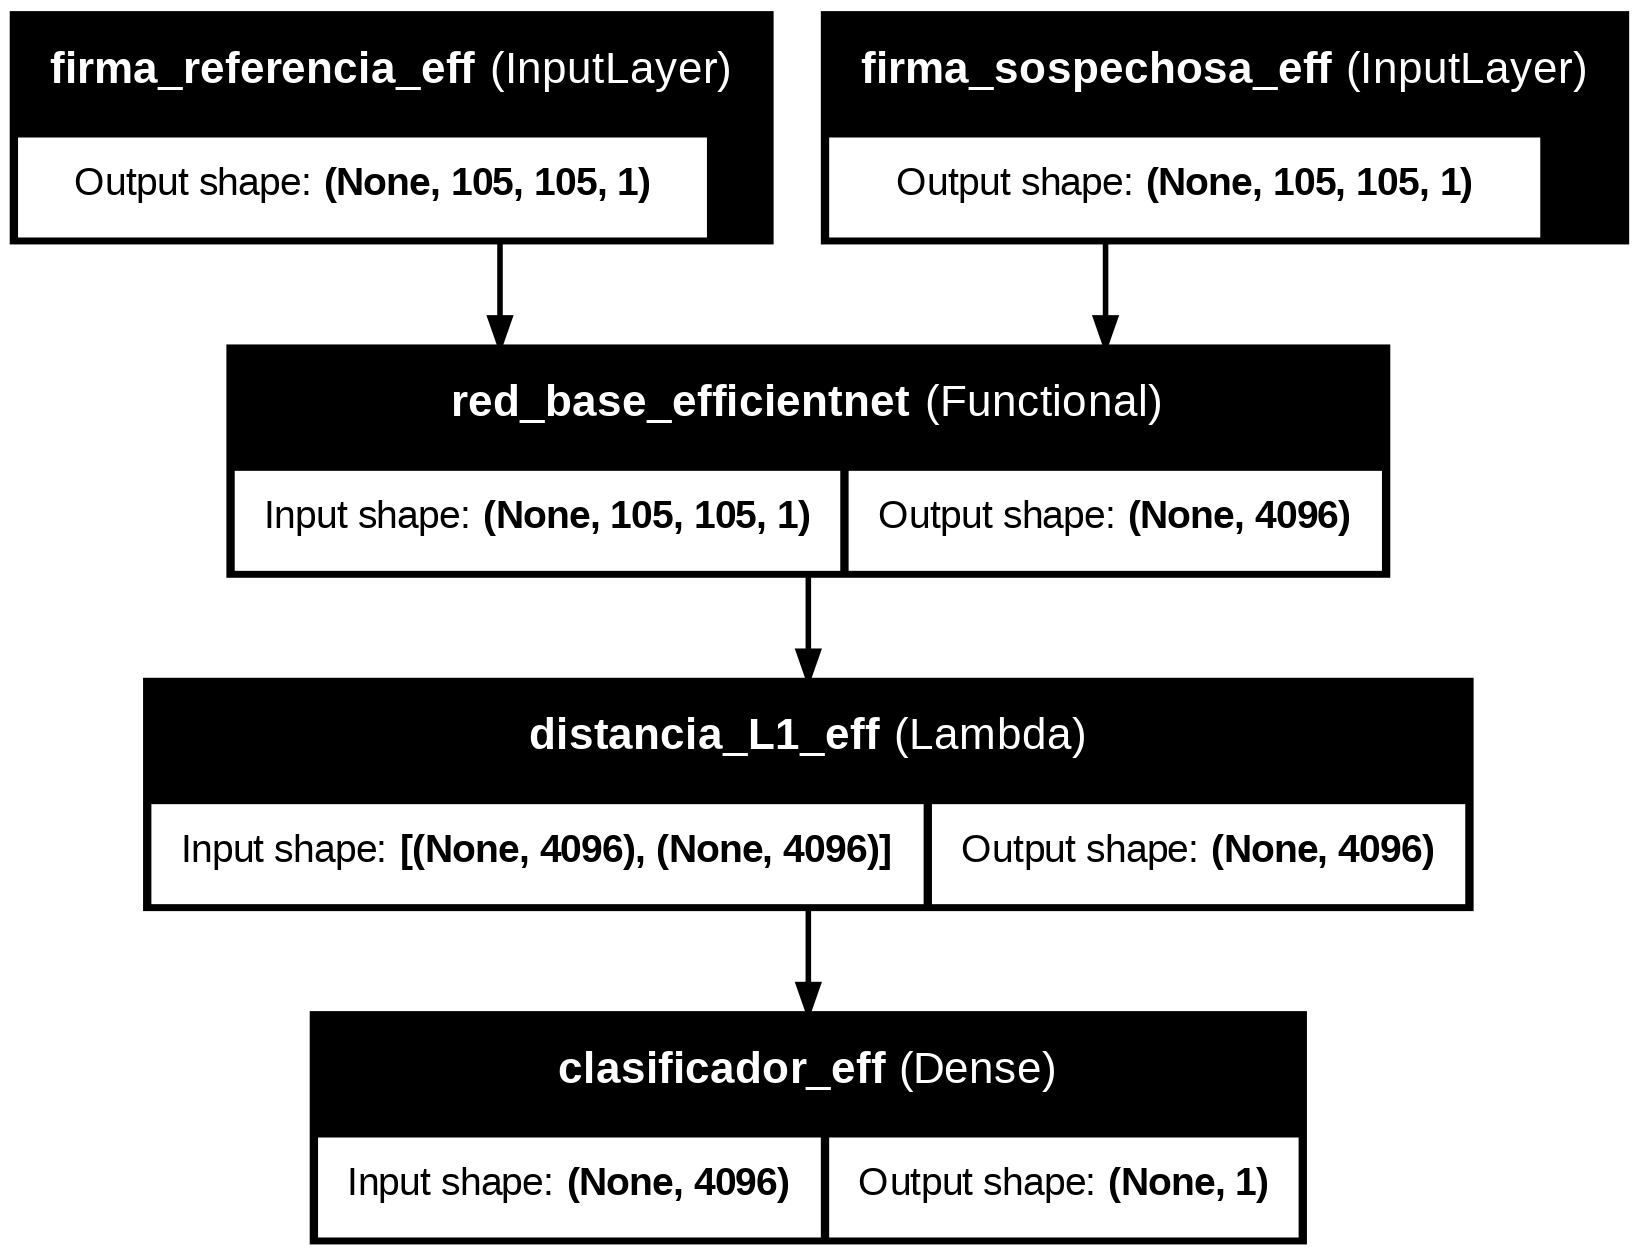

In [15]:
# Diagrama visual de la arquitectura con EfficientNetB0
keras.utils.plot_model(modelo_siames_eff, show_shapes=True, show_layer_names=True)

Esta arquitectura mantiene la estructura del primer modelo de red siamesa con base CNN, pero al incluir una sección de preentrenamiento, es más eficiente aunque restringido a los resultados del preentrenamiento.

### **3.4. Comparación de arquitecturas**
---

Antes de entrenar, comparamos el número de parámetros y la estrategia de cada modelo:

In [13]:
# Tabla comparativa de arquitecturas
params_m1 = modelo_siames.count_params()
params_m2 = modelo_siames_eff.count_params()

print("=" * 60)
print("          COMPARACIÓN DE ARQUITECTURAS")
print("=" * 60)
print(f"  {'Modelo':<35} {'Parámetros':>12}")
print("-" * 60)
print(f"  {'Red Siamesa + CNN base':<35} {params_m1:>12,}")
print(f"  {'Red Siamesa + EfficientNetB0':<35} {params_m2:>12,}")
print("=" * 60)
print("\nEstrategia de entrenamiento:")
print("  Modelo 1 → Entrenado desde cero (pesos aleatorios)")
print("  Modelo 2 → Transfer Learning (EfficientNet congelado)")

          COMPARACIÓN DE ARQUITECTURAS
  Modelo                                Parámetros
------------------------------------------------------------
  Red Siamesa + CNN base                43,145,793
  Red Siamesa + EfficientNetB0           6,810,794

Estrategia de entrenamiento:
  Modelo 1 → Entrenado desde cero (pesos aleatorios)
  Modelo 2 → Transfer Learning (EfficientNet congelado)


**Conclusión del diseño experimental:**

* El **Modelo 1 (CNN base)** aprenderá representaciones específicas del dominio de firmas desde cero, con mayor flexibilidad pero mayor necesidad de datos.
* El **Modelo 2 (EfficientNetB0)** reutiliza características aprendidas en ImageNet. Dado que las firmas son imágenes monocromáticas muy diferentes de las imágenes naturales de ImageNet, se espera que el Transfer Learning sea menos efectivo aquí que en problemas de visión natural — lo cual es una hipótesis experimental que se verificará en M5U5.
* Ambos modelos usan la misma estructura Siamesa (pesos compartidos + distancia L1 + clasificador sigmoide), permitiendo una **comparación justa** de las redes base.
* El entrenamiento, selección de hiperparámetros y evaluación comparativa se realizarán en el notebook **M5U5**.

# **Créditos**
---

* **Profesor:** [Fabio Augusto Gonzalez](https://dis.unal.edu.co/~fgonza/)
* **Asistentes docentes :**
  * [Santiago Toledo Cortés](https://sites.google.com/unal.edu.co/santiagotoledo-cortes/)
* **Diseño de imágenes:**
    - [Mario Andres Rodriguez Triana](mailto:mrodrigueztr@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*